# Exercícios 18/09

## Utilizando o dataset do Titanic, realize o que se pede:



### Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower

from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

df = pd.read_csv('/content/gdrive/My Drive/AVD/titanic.csv')
df.head(5)

Mounted at /content/gdrive


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###1. Teste de Hipóteses (Teste t para Médias)

**Teste a hipótese de que a média das idades dos sobreviventes e dos não sobreviventes é igual.**

* Hipótese Nula (H₀): A média das idades dos sobreviventes é igual à média das idades dos não sobreviventes.

* Hipótese Alternativa (H₁): A média das idades dos sobreviventes é diferente da média das idades dos não sobreviventes.

In [ ]:
sAge = df[df['Survived'] == 1]['Age'].dropna()
nsAge = df[df['Survived'] == 0]['Age'].dropna()

mediaS = sAge.mean()
mediaNS = nsAge.mean()

t_statistic, p_value = stats.ttest_ind(sAge, nsAge, alternative='two-sided')

print(f'Média das idades dos sobreviventes: {mediaS}')
print(f'Média das idades dos não sobreviventes: {mediaNS}')
print(f"Estatística t: {t_statistic}")
print(f"Valor p: {p_value}")

if p_value < 0.05:
    print('Rejeitamos a Hipótese Nula. A média das idades dos sobreviventes é diferente da média das idades dos não sobreviventes.')
else:
    print('Falhamos em rejeitar a Hipótese Nula. A média das idades dos sobreviventes é diferente da média das idades dos não sobreviventes.')

Média das idades dos sobreviventes: 28.343689655172415
Média das idades dos não sobreviventes: 30.62617924528302
Estatística t: -2.06668694625381
Valor p: 0.03912465401348249
Rejeitamos a Hipótese Nula. A média das idades dos sobreviventes é diferente da média das idades dos não sobreviventes.


###2. Intervalo de Confiança

**Calcule o intervalo de confiança de 95% para a média de idades dos passageiros.**

Calcule o intervalo de confiança para a média de idade usando um nível de confiança de 95%.

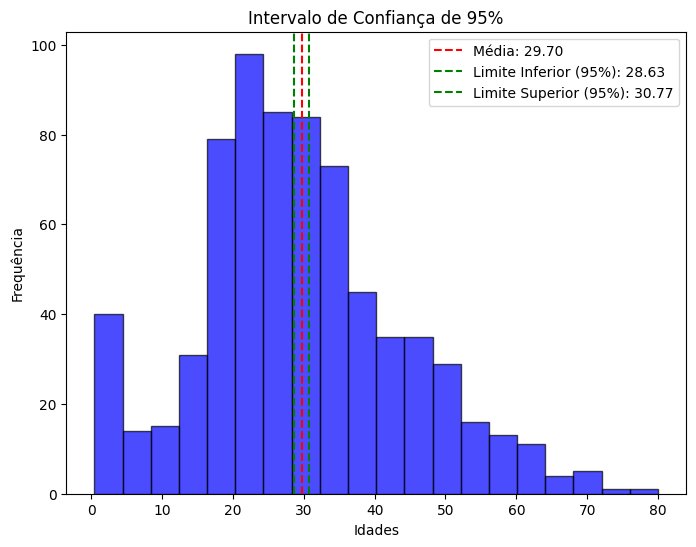

In [ ]:
mean = np.mean(df['Age'])
n = len(df['Age'].dropna())
desvioPadrao = df['Age'].std()
erroPadrao = desvioPadrao / np.sqrt(n)
confidence_interval = stats.t.interval(0.95, df=n-1, loc=mean, scale=erroPadrao)

plt.figure(figsize=(8, 6))
plt.hist(df['Age'], bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(mean, color='red', linestyle='--', label=f'Média: {mean:.2f}')
plt.axvline(confidence_interval[0], color='green', linestyle='--', label=f'Limite Inferior (95%): {confidence_interval[0]:.2f}')
plt.axvline(confidence_interval[1], color='green', linestyle='--', label=f'Limite Superior (95%): {confidence_interval[1]:.2f}')
plt.title('Intervalo de Confiança de 95%')
plt.xlabel('Idades')
plt.ylabel('Frequência')
plt.legend()
plt.show()

###3. Significância Estatística

**Verifique se há uma diferença estatisticamente significativa entre a proporção de sobreviventes homens e mulheres no Titanic.**

* Hipótese Nula (H₀): A proporção de sobreviventes é igual entre homens e
mulheres.

* Hipótese Alternativa (H₁): A proporção de sobreviventes é diferente entre homens e mulheres.


Estatística t: 8.843
Valor p: 0.000


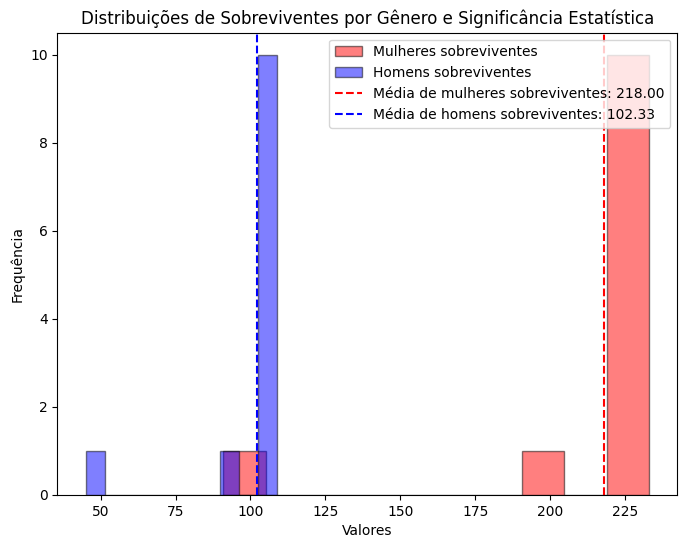

O resultado é estatisticamente significativo (p < 0.05)


In [ ]:
hSobreviventes = df[(df['Sex'] == 'male') & (df['Survived'] == 1)].count()
mSobreviventes = df[(df['Sex'] == 'female') & (df['Survived'] == 1)].count()

stat, p_value = stats.ttest_ind(mSobreviventes, hSobreviventes, alternative='two-sided')

print(f'Estatística t: {stat:.3f}')
print(f'Valor p: {p_value:.3f}')

plt.figure(figsize=(8, 6))
plt.hist(mSobreviventes, alpha=0.5, label='Mulheres sobreviventes', color='red', edgecolor='black')
plt.hist(hSobreviventes, alpha=0.5, label='Homens sobreviventes', color='blue', edgecolor='black')
plt.axvline(np.mean(mSobreviventes), color='red', linestyle='--', label=f'Média de mulheres sobreviventes: {np.mean(mSobreviventes):.2f}')
plt.axvline(np.mean(hSobreviventes), color='blue', linestyle='--', label=f'Média de homens sobreviventes: {np.mean(hSobreviventes):.2f}')
plt.title('Distribuições de Sobreviventes por Gênero e Significância Estatística')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.legend()
plt.show()

if p_value < 0.05:
    print('O resultado é estatisticamente significativo (p < 0.05)')
else:
    print('O resultado não é estatisticamente significativo (p >= 0.05)')

###4. Grau de Confiança

**Calcule e compare os intervalos de confiança de 90%, 95%, e 99% para a média da idade dos passageiros no Titanic.**

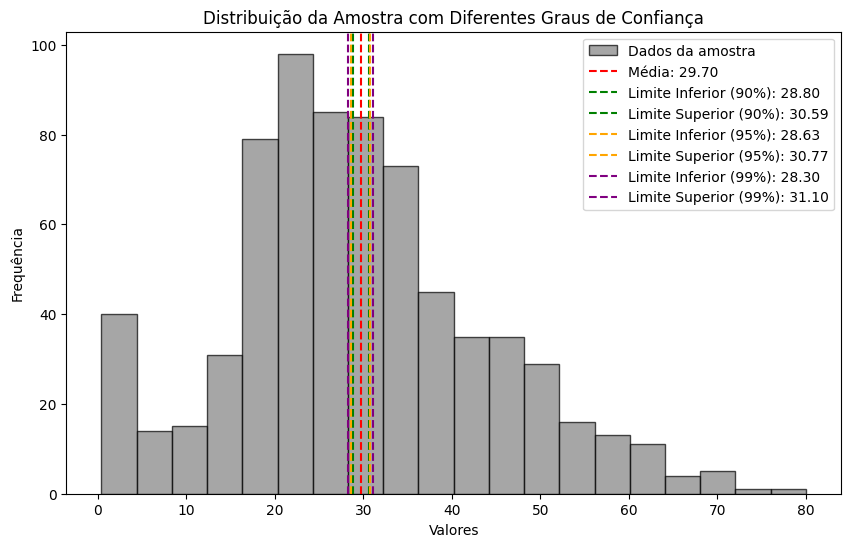

In [ ]:
mean = np.mean(df['Age'])
n = len(df['Age'].dropna())
desvioPadrao = df['Age'].std()
erroPadrao = desvioPadrao / np.sqrt(n)

confidence_levels = [0.90, 0.95, 0.99]
confidence_intervals = [stats.t.interval(cl, df=n-1, loc=mean, scale=erroPadrao) for cl in confidence_levels]

plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=20, alpha=0.7, color='gray', edgecolor='black', label='Dados da amostra')
plt.axvline(mean, color='red', linestyle='--', label=f'Média: {mean:.2f}')

colors = ['green', 'orange', 'purple']
for i, (cl, ci) in enumerate(zip(confidence_levels, confidence_intervals)):
    plt.axvline(ci[0], color=colors[i], linestyle='--', label=f'Limite Inferior ({int(cl*100)}%): {ci[0]:.2f}')
    plt.axvline(ci[1], color=colors[i], linestyle='--', label=f'Limite Superior ({int(cl*100)}%): {ci[1]:.2f}')

plt.title('Distribuição da Amostra com Diferentes Graus de Confiança')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.legend()
plt.show()

###5. Potência Estatística

**Estime o tamanho da amostra necessário para detectar uma diferença na proporção de sobreviventes entre homens e mulheres, com uma potência de 80%.**

Tamanho da amostra necessário para detectar a diferença na proporção de sobreviventes entre homens e mulheres com uma potência de 80%: 52


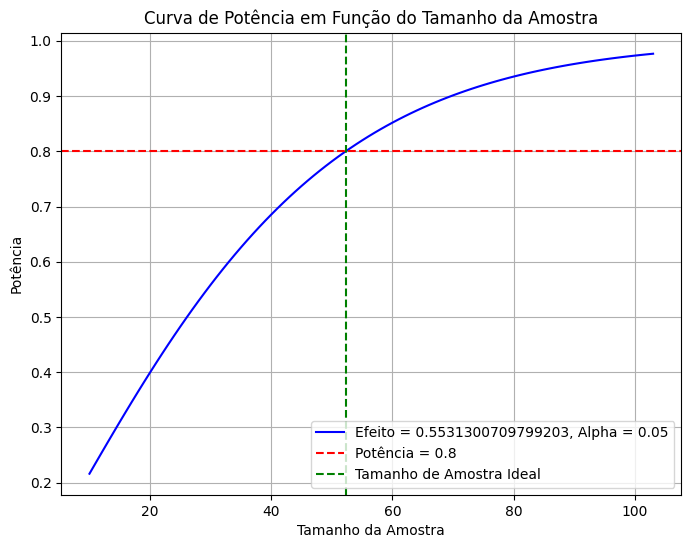

In [ ]:
propH = df[df['Sex'] == 'male']['Survived'].mean()
propM = df[df['Sex'] == 'female']['Survived'].mean()
effect_size = propM - propH
alpha = 0.05
power_target = 0.8

analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, power=power_target, alpha=alpha, ratio=1)

sample_sizes = np.arange(10, int(sample_size * 2), 1)
powers = [analysis.solve_power(effect_size=effect_size, nobs1=n, alpha=alpha, power=None, alternative='two-sided') for n in sample_sizes]

print(f"Tamanho da amostra necessário para detectar a diferença na proporção de sobreviventes entre homens e mulheres com uma potência de 80%: {sample_size:.0f}")

plt.figure(figsize=(8, 6))
plt.plot(sample_sizes, powers, label=f'Efeito = {effect_size}, Alpha = {alpha}', color='blue')
plt.axhline(y=power_target, color='red', linestyle='--', label=f'Potência = {power_target}')
plt.axvline(x=sample_size, color='green', linestyle='--', label='Tamanho de Amostra Ideal')

plt.title('Curva de Potência em Função do Tamanho da Amostra')
plt.xlabel('Tamanho da Amostra')
plt.ylabel('Potência')
plt.legend()
plt.grid(True)
plt.show()